# Scénario 3 — prix flexibles, paramétrable

Choc **donné** : montants annuels ex-ante lus dans `fep_sc3.xlsx` (AS1:AW1, croissants ≈ 56 → 120 M€/an),
adaptés chaque année par le double effet (glissement + assiette). Emplois détruits : colonne P (ε−0,6) /
Q (ε−0,9), reproduits au prorata du choc adapté.

Transmission **identique au scénario 1** (même moteur `sc12_flex`), **sans productivité**, en **euros
constants** :

- **Prix** : **clauses** (immédiat, % du choc) + **répercussion** = taux ANNUEL de reflux du buffer vers
  les prix (33 %/an ≈ contrats de 3 ans repricés intégralement).
- **Reste** réparti **marges / moindres salaires** (ratio **1/3 – 2/3** par défaut), marges plafonnées
  (**5 %** du résultat net) ; **≤ 1,2 SMIC protégés (+2,3 %)**.
- **Compte de l'État branché sur la distribution** : cotisations perdues au taux du niveau de chaque
  emploi détruit ; chômage au **recours 100 %** (650 € × 12).

Indicateurs réglables : `plafond_marges`, `pct_clauses`, `pct_repercussion`, `ratio_marges`,
`proteger_bas`, `euros_constants`.

In [1]:
%matplotlib inline
import sys
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

def dossier_modele(fichier="sc3_flex.py"):
    """Localise 01_code/python_modele_fep quel que soit le dossier de lancement de Jupyter.

    Remonte l'arborescence depuis le dossier courant : marche depuis 01_code/notebooks/,
    depuis la racine du projet, depuis 01_code/, ou depuis le dossier parent du projet.
    Les chemins de DONNÉES, eux, sont résolus par config.py depuis son propre emplacement :
    ils sont corrects dès que le module est importable.
    """
    formes = ("01_code/python_modele_fep", "python_modele_fep", ".",
              "projet_fep/01_code/python_modele_fep")
    for base in [Path.cwd(), *Path.cwd().parents]:
        for forme in formes:
            cand = (base / forme).resolve()
            if (cand / fichier).exists():
                return cand
    raise FileNotFoundError(
        f"{fichier} introuvable en remontant depuis {Path.cwd()}.\n"
        "Lance Jupyter depuis la racine du projet (projet_fep/) "
        "ou depuis 01_code/notebooks/.")

MODELE = dossier_modele()
if str(MODELE) not in sys.path:
    sys.path.insert(0, str(MODELE))
print("modèle chargé depuis :", MODELE)

import sc3_flex as F
import config as cfg
print("données lues dans    :", cfg.DOSSIER_SOURCES)

COULS = {"prix_MEUR":"#378ADD","emplois_MEUR":"#E24B4A","moindres_salaires_MEUR":"#EF9F27",
         "marges_MEUR":"#7F77DD","residu_MEUR":"#888780"}
NOMS  = {"prix_MEUR":"Prix","emplois_MEUR":"Emplois","moindres_salaires_MEUR":"Moindres salaires",
         "marges_MEUR":"Marges","residu_MEUR":"Résidu"}

def afficher(plafond_marges=0.05, pct_clauses=0.35, pct_repercussion=1/3,
             ratio_marges=1/3, proteger_bas=True, euros_constants=True, elasticite_06=True):
    r = F.simuler(plafond_marges, pct_clauses, pct_repercussion, ratio_marges,
                  proteger_bas, euros_constants, elasticite_haute=not elasticite_06)
    ic = r["vue"]; unite = "constants" if euros_constants else "nominaux"
    fig, ax = plt.subplots(figsize=(9,4.6))
    cols = list(COULS)
    ax.stackplot(ic["annee"], *[ic[c] for c in cols], labels=[NOMS[c] for c in cols],
                 colors=[COULS[c] for c in cols], alpha=0.9)
    ax.axvline(5.5, color="k", ls="--", lw=1); ax.set_xlim(1,10)
    ax.set_xlabel("Année"); ax.set_ylabel(f"M€ {unite} / an")
    ax.set_title(f"Scénario 3 — absorption du surcoût sur 10 ans (euros {unite})")
    ax.legend(loc="upper left", fontsize=9, ncol=2)
    plt.tight_layout(); display(fig); plt.close(fig)
    display(F.table_resultats(r))
    return r

modèle chargé depuis : C:\Users\cga\Desktop\projet_fep\01_code\python_modele_fep


données lues dans    : C:\Users\cga\Desktop\projet_fep\02_donnees\sources\references_modele


## Cas de base — plafond marges 5 %, clauses 35 %, répercussion 33 %/an, ratio 1/3, ≤1,2 protégés

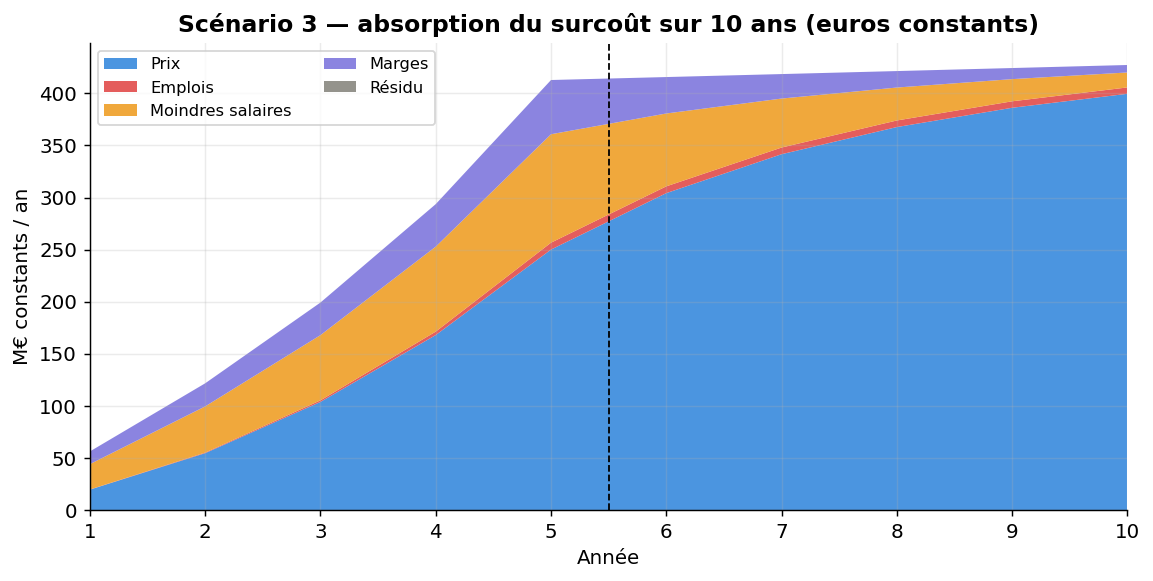

,Indicateur,Valeur
0,"Surcoût total (N+5, € constants)",413 M€
1,→ Prix (clauses),142 M€
2,→ Prix (répercussion),108 M€
3,→ Moindres salaires,104 M€
4,→ Marges,52 M€
5,"→ Emplois (coût absorbé, ε−0,6)",6.6 M€
6,→ Résidu,0 M€
7,Marges (% résultat net),4.8 %
8,Part prix (%),61 %
9,"Hausse salaires >1,2 SMIC",+1.84 %


In [2]:
_ = afficher()

## Faire varier les indicateurs

Exemples : `afficher(pct_clauses=0.5, pct_repercussion=1.0)`, `afficher(plafond_marges=0.10)`,
`afficher(ratio_marges=0.5)`, `afficher(euros_constants=False)` (nominal).

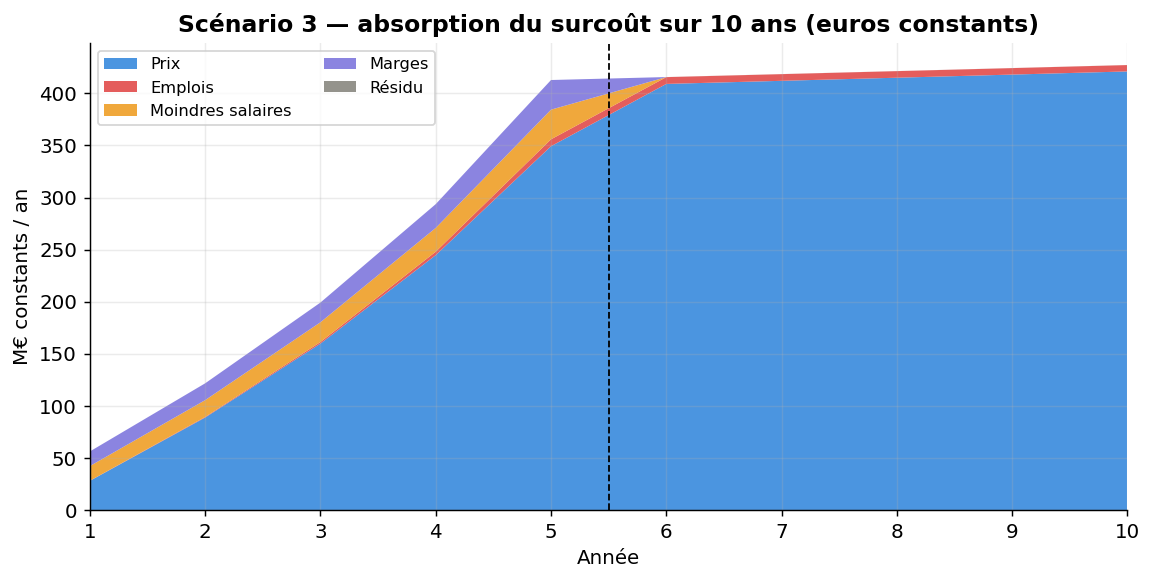

,Indicateur,Valeur
0,"Surcoût total (N+5, € constants)",413 M€
1,→ Prix (clauses),203 M€
2,→ Prix (répercussion),146 M€
3,→ Moindres salaires,28 M€
4,→ Marges,28 M€
5,"→ Emplois (coût absorbé, ε−0,6)",6.6 M€
6,→ Résidu,0 M€
7,Marges (% résultat net),2.6 %
8,Part prix (%),85 %
9,"Hausse salaires >1,2 SMIC",+2.18 %


In [3]:
_ = afficher(pct_clauses=0.50, pct_repercussion=1.0, ratio_marges=0.5)

## Curseurs interactifs (ipywidgets)

`pip install ipywidgets` pour activer les curseurs (recalcul du graphique + table en direct).

In [4]:
try:
    import ipywidgets as W
    W.interact(afficher,
        plafond_marges=W.FloatSlider(min=0, max=0.25, step=0.01, value=0.05, description="plaf. marges"),
        pct_clauses=W.FloatSlider(min=0, max=1, step=0.05, value=0.35, description="clauses"),
        pct_repercussion=W.FloatSlider(min=0, max=1, step=0.05, value=1/3, description="répercussion/an"),
        ratio_marges=W.FloatSlider(min=0, max=1, step=0.01, value=1/3, readout_format=".2f", description="ratio marges"),
        proteger_bas=W.Checkbox(value=True, description="protéger ≤1,2 SMIC"),
        euros_constants=W.Checkbox(value=True, description="euros constants"),
        elasticite_06=W.Checkbox(value=True, description="élasticité −0,6 (sinon −0,9)"))
except ModuleNotFoundError:
    print("ipywidgets non installé -> 'pip install ipywidgets'. En attendant, appelle afficher(...).")

interactive(children=(FloatSlider(value=0.05, description='plaf. marges', max=0.25, step=0.01), FloatSlider(va…